# Array topology sweep — escenas aleatorias 3D (arreglo sobre bafle)

Compara las **5 topologías** de arreglo (2D, inscriptas en un círculo del mismo
diámetro, mismo `M`) bajo un **muestreo aleatorio de escenas 3D**, para ver qué
topología es más robusta a posiciones arbitrarias de fuente e interferencia.

**Bafle (piso):** el arreglo es planar en XY y se apoya **flush sobre el piso**
(`BAFFLE_HEIGHT` ≈ 0.5 cm), que actúa de bafle horizontal — el caso normal de un
dispositivo apoyado sobre una mesa/superficie. Su broadside mira hacia arriba, así
que las fuentes viven en el **domo superior** (elevación ≥ 0; una fuente bajo el
piso rompe ISM). El material del piso no es rígido (mismo α del RT60), así que el
bafle es **parcial**.

**Escenas aleatorias (pares target–interferencia 1:1):**

- **Target**: **volumen de medio cascarón** (domo) **concéntrico** al arreglo —
  radio 0.7–1.5 m (con profundidad), dirección uniforme en ángulo sólido sobre el
  domo (azimut 0–360°, elevación 3–85°).
- **Interferencia**: **aleatoria en toda la sala** — azimut 0–360°, elevación 2–60°
  (siempre sobre el bafle), distancia aleatoria, recortada por pared con
  `max_distance_in_room`.
- Cada escena empareja **un** target con **una** interferencia (no se cruzan todas
  contra todas). Se generan `N_SCENES` geometrías, reutilizadas en las 3 salas para
  aislar el efecto de la reverberación.

**Salas / RT60** realistas (oficina 0.3 s · aula 0.5 s · salón 0.8 s). El arreglo se
**centra** en cada sala para que el domo concéntrico de 1.5 m entre completo.

**Algoritmos:** `DS` (directividad geométrica cruda) y `SOUDEN_ORACLE_SCM` (cota
superior estadística). El par acota el comportamiento de cada topología.

**Tamaño:** 3 salas × `N_SCENES` escenas × 5 topologías × 2 algoritmos.

**Orden:** Setup → Config (RNG) → **Escena 3D (pre-vuelo)** → Run → Resultados.

## Setup

In [2]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = "/home/matias/Documents/Tesis/Vision-Aided-Beamformer"
SRC = os.path.join(REPO_ROOT, "src")
for p in (REPO_ROOT, SRC):
    if p not in sys.path:
        sys.path.insert(0, p)
os.chdir(SRC)

from evaluation.full_benchmark_test_dtln import run_grid_search
from evaluation.bf_wrappers import DS, SOUDEN_ORACLE_SCM
from beamforming.array.geometry import (generate_array_coords, place_spherical,
                                        max_distance_in_room)
print('[*] Setup OK')


I0000 00:00:1787755296.572455 1450328 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787755296.573025 1450328 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787755296.613880 1450328 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787755297.676703 1450328 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_E

[*] Setup OK


## Config — salas + generador aleatorio de escenas

Lo *físico* se define acá. El arreglo se apoya **flush sobre el piso**
(`BAFFLE_HEIGHT`), que hace de **bafle horizontal**; su broadside mira hacia arriba,
así que todo vive en el **domo superior** (elevación ≥ 0). Las escenas se
**muestrean al azar** con un RNG sembrado (reproducible). Cada escena es un par
`(target, interferencia)`:

- **Target** — **volumen de medio cascarón** (domo) concéntrico al arreglo: radio
  slant uniforme en `TARGET_R_RANGE` (0.7–1.5 m, le da profundidad), dirección
  **uniforme en ángulo sólido** (azimut 0–360°, elevación en `TARGET_EL_RANGE`) para
  llenar el domo sin apelmazar en el cenit.
- **Interferencia** — azimut 0–360°, elevación en `INTERF_EL_RANGE` (≥ 0, sobre el
  bafle), distancia uniforme en `INTERF_DIST_RANGE`. El motor recorta con
  `max_distance_in_room`.

Para que el domo concéntrico de radio hasta 1.5 m entre completo, el arreglo se
**centra** en cada sala (deja ≥ `R_max + WALL_MARGIN` de aire en X e Y; ya no está
pegado a la pared trasera).

Las `N_SCENES` geometrías se generan **una vez** (independientes de la sala) y se
reutilizan en las 3 salas, así la comparación entre topologías y entre salas ve las
mismas direcciones/distancias relativas. Todo se pasa al motor como `source_specs`
(target por-escena) e `interf_scenarios` (interferencia por-escena).

In [3]:
# --------------------------- ARREGLO (fijo) ---------------------------
M        = 12
DIAMETER = 0.15
TOPOLOGIES = ['circular', 'grid', 'spiral', 'concentric']

# --------------------------- SALAS / RT60 -----------------------------
ROOM_PROFILES = {
    0.30: np.array([6.0, 7.0, 2.8]),   # oficina
    0.50: np.array([7.0, 8.0, 3.0]),   # aula
    0.80: np.array([9.0, 11.0, 3.5]),  # salon
}

# --------- BAFLE HORIZONTAL: arreglo apoyado (flush) sobre el PISO ---------
# El arreglo es planar en XY y se apoya flush sobre el piso (limite z=0 de la
# ShoeBox), que actua de bafle horizontal. Su broadside apunta hacia ARRIBA (+Z), asi
# que las fuentes viven en el DOMO superior (elevacion >= 0): el piso corta la esfera
# a la mitad => "medio cascaron". El material del piso NO es rigido (mismo alpha del
# RT60) => bafle PARCIAL (~1.75x), compromiso asumido.
BAFFLE_HEIGHT = 0.005   # 0.5 cm sobre el piso (flush)

# El TARGET usa un medio-cascaron CONCENTRICO de radio hasta TARGET_R_RANGE[1]. Para
# que ese domo entre completo (360 de azimut) hay que dejar >= R_max + WALL_MARGIN de
# aire en X e Y alrededor del arreglo => se centra (ya no pegado a la pared trasera).
ARRAY_CENTER_MAP = {
    0.30: np.array([3.0, 2.5, BAFFLE_HEIGHT]),
    0.50: np.array([3.5, 3.0, BAFFLE_HEIGHT]),
    0.80: np.array([4.5, 3.5, BAFFLE_HEIGHT]),
}

# =========== GENERADOR ALEATORIO DE ESCENAS (target + interf 1:1) ==========
N_SCENES = 90          # escenas aleatorias (por sala; mismas geometrias en las 3)
RNG_SEED = 2026         # reproducible

# --- TARGET: VOLUMEN de medio-cascaron (domo superior) concentrico al arreglo ---
# Direccion muestreada UNIFORME EN ANGULO SOLIDO (arcsin) para llenar el domo sin
# apelmazar en el cenit; radio uniforme en el rango pedido (le da profundidad).
TARGET_R_RANGE  = (0.70, 1.50)      # radio slant [m]: cascaron con profundidad (volumen)
TARGET_EL_RANGE = (3.0, 85.0)       # elevacion [deg]: 0=plano del bafle, 90=cenit

# --- INTERFERENCIA: aleatoria en la sala, SIEMPRE por encima del bafle ---
INTERF_EL_RANGE   = (2.0, 60.0)     # elevacion >= 0 (arreglo en el piso): nada bajo el piso
INTERF_DIST_RANGE = (1.0, 3.0)      # distancia slant [m] (se recorta a la sala)

# ------------------------- muestreo de las escenas -------------------------
_rng = np.random.default_rng(RNG_SEED)
_sin_lo, _sin_hi = np.sin(np.deg2rad(TARGET_EL_RANGE))
SCENE_IDS     = [f'sc{i:02d}' for i in range(N_SCENES)]
SOURCE_SPECS  = {}   # {scene_id -> (az, el, dist)}            target (domo volumetrico)
INTERF_SCENARIOS = {}  # {scene_id -> [(az, el, dist)]}        1 interferencia
for sid in SCENE_IDS:
    t_az = _rng.uniform(0.0, 360.0)
    t_el = np.rad2deg(np.arcsin(_rng.uniform(_sin_lo, _sin_hi)))  # solido-angulo uniforme
    t_r  = _rng.uniform(*TARGET_R_RANGE)
    SOURCE_SPECS[sid] = (t_az, t_el, t_r)
    i_az = _rng.uniform(0.0, 360.0)
    i_el = _rng.uniform(*INTERF_EL_RANGE)
    i_d  = _rng.uniform(*INTERF_DIST_RANGE)
    INTERF_SCENARIOS[sid] = [(i_az, i_el, i_d)]

# --------------------------- ESCENA (fija) ----------------------------
ISIR_DB      = 0        # interferencia total tan fuerte como el target
DURATION     = 15
RAY_TRACING  = False  # OFF (ademas el motor v1 usa ISM puro calibrado; el flag se ignora)
WALL_MARGIN  = 0.3
SAVE_CATALOG = False

print('Salas/RT:', list(ROOM_PROFILES))
print(f'Bafle: arreglo flush a {BAFFLE_HEIGHT*100:.1f} cm del piso (plano XY, centrado) | domo superior')
print(f'Ray tracing: {RAY_TRACING} (motor v1 = ISM puro calibrado)')
print(f'Escenas aleatorias: {N_SCENES} (seed={RNG_SEED}) | 1 interf/escena')
print(f'Target (medio cascaron volumetrico): r{TARGET_R_RANGE} m, az(0,360) deg, el{TARGET_EL_RANGE} deg')
print(f'Interf: az(0,360) deg, el{INTERF_EL_RANGE} deg, dist{INTERF_DIST_RANGE} m')
n_scenes = len(ROOM_PROFILES) * N_SCENES * len(TOPOLOGIES)
print(f'Escenas fisicas: {n_scenes}  |  filas: {n_scenes * 2}')
print('Ej. sc00 -> target', tuple(round(v, 1) for v in SOURCE_SPECS["sc00"]),
      '| interf', tuple(round(v, 1) for v in INTERF_SCENARIOS["sc00"][0]))

Salas/RT: [0.3, 0.5, 0.8]
Bafle: arreglo flush a 0.5 cm del piso (plano XY, centrado) | domo superior
Ray tracing: False (motor v1 = ISM puro calibrado)
Escenas aleatorias: 90 (seed=2026) | 1 interf/escena
Target (medio cascaron volumetrico): r(0.7, 1.5) m, az(0,360) deg, el(3.0, 85.0) deg
Interf: az(0,360) deg, el(2.0, 60.0) deg, dist(1.0, 3.0) m
Escenas fisicas: 1080  |  filas: 2160
Ej. sc00 -> target (64.4, np.float64(41.0), 1.1) | interf (133.4, 22.6, 2.6)


## Escena 3D — pre-vuelo

Reconstruye las posiciones **con la misma lógica que el motor** (`place_spherical` +
recorte de pared `max_distance_in_room` + override por-escena `source_specs`), para
**verificar antes de correr** dónde caen los `N_SCENES` targets (**medio cascarón /
domo** volumétrico de 0.7–1.5 m, concéntrico al arreglo) y las interferencias
aleatorias. Vista **3D** de la sala elegida con la caja de la sala, el bafle (piso),
los micrófonos y las nubes de target/interferencia.

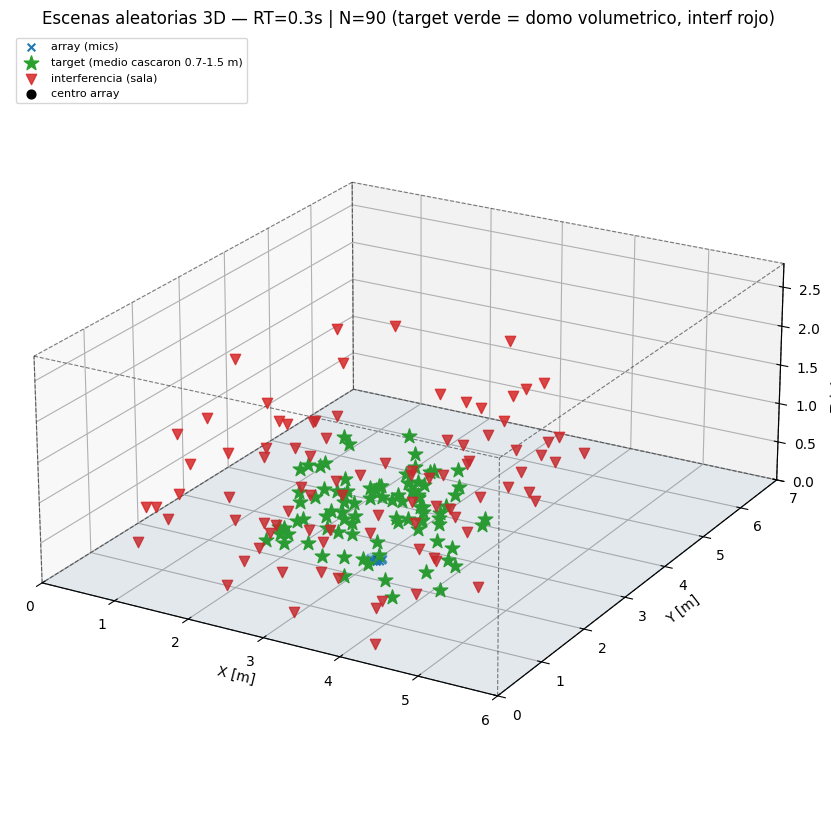

Target: radio 0.71-1.50 m (pedido (0.7, 1.5)) | altura 0.07-1.42 m sobre el piso
Interf: distancia media al centro 2.05 m


In [4]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (habilita proj 3D)


def build_all_positions(rt60, topology='circular'):
    """Reconstruye, tal cual el motor, las posiciones de TODAS las escenas para una
    sala: array (topologia dada), y para cada scene_id su target (source_specs) e
    interferencia (interf_scenarios), recortadas por pared. Devuelve
    (array_center, mic_coords, targets[N,3], interfs[N,3]).
    Usa COPIAS de room/ac para que NADA aguas abajo pueda mutar en sitio los dicts
    ROOM_PROFILES / ARRAY_CENTER_MAP."""
    room = np.asarray(ROOM_PROFILES[rt60], dtype=float).copy()
    ac   = np.asarray(ARRAY_CENTER_MAP[rt60], dtype=float).copy()
    mic  = generate_array_coords(topology, M, DIAMETER) + ac
    tgt, itf = [], []
    for sid in SCENE_IDS:
        t_az, t_el, t_d = SOURCE_SPECS[sid]
        t_d = min(t_d, max_distance_in_room(t_az, t_el, ac, room, WALL_MARGIN))
        tgt.append(place_spherical(t_az, t_el, t_d, ac))
        i_az, i_el, i_d = INTERF_SCENARIOS[sid][0]
        i_d = min(i_d, max_distance_in_room(i_az, i_el, ac, room, WALL_MARGIN))
        itf.append(place_spherical(i_az, i_el, i_d, ac))
    return ac, mic, np.array(tgt), np.array(itf)


def _draw_room_box(ax, room, **kw):
    x, y, z = room
    corners = np.array([[0, 0, 0], [x, 0, 0], [x, y, 0], [0, y, 0],
                        [0, 0, z], [x, 0, z], [x, y, z], [0, y, z]])
    edges = [(0, 1), (1, 2), (2, 3), (3, 0), (4, 5), (5, 6), (6, 7), (7, 4),
             (0, 4), (1, 5), (2, 6), (3, 7)]
    for a, b in edges:
        ax.plot(*zip(corners[a], corners[b]), **kw)


# Muestra la sala A (RT=0.3) con las N escenas aleatorias en 3D.
RT_SHOW = 0.30
ac, mic, tgt, itf = build_all_positions(RT_SHOW)
room = np.asarray(ROOM_PROFILES[RT_SHOW], dtype=float).copy()  # COPIA: el plot no debe tocar el dict

fig = plt.figure(figsize=(11, 8.5))
axx = fig.add_subplot(111, projection='3d')
_draw_room_box(axx, room, color='k', ls='--', lw=0.8, alpha=0.5)
# bafle (piso, z=0) como una malla tenue
axx.plot_trisurf([0, room[0], room[0], 0], [0, 0, room[1], room[1]],
                 [0, 0, 0, 0], color='tab:blue', alpha=0.08)
axx.scatter(mic[:, 0], mic[:, 1], mic[:, 2], c='tab:blue', marker='x', s=30, label='array (mics)')
axx.scatter(tgt[:, 0], tgt[:, 1], tgt[:, 2], c='tab:green', marker='*', s=120,
            depthshade=False, label=f'target (medio cascaron {TARGET_R_RANGE[0]}-{TARGET_R_RANGE[1]} m)')
axx.scatter(itf[:, 0], itf[:, 1], itf[:, 2], c='tab:red', marker='v', s=55,
            depthshade=False, alpha=0.85, label='interferencia (sala)')
axx.scatter(*ac, c='k', marker='o', s=40, label='centro array')

axx.set(xlabel='X [m]', ylabel='Y [m]', zlabel='Z (altura) [m]',
        xlim=(0, room[0]), ylim=(0, room[1]), zlim=(0, room[2]))
axx.set_title(f'Escenas aleatorias 3D — RT={RT_SHOW}s | N={N_SCENES} '
              f'(target verde = domo volumetrico, interf rojo)')
axx.view_init(elev=22, azim=-60)
axx.legend(loc='upper left', fontsize=8)
try:
    # IMPORTANTE: matplotlib set_box_aspect hace 'aspect *= const/norm' EN SITIO.
    # Se le pasa una TUPLA (secuencia nueva), no el ndarray, para que no pueda mutar
    # 'room' (y con ello ROOM_PROFILES). Este bug corrompia la sala 0.30.
    axx.set_box_aspect(tuple(float(v) for v in room))
except Exception:
    pass
plt.tight_layout(); plt.show()

# Sanity: el ploteo NO debe haber tocado los dicts de config.
assert np.allclose(ROOM_PROFILES[RT_SHOW], [6.0, 7.0, 2.8]), \
    'ROOM_PROFILES fue mutado por el plot (revisa set_box_aspect).'

r_tgt = np.linalg.norm(tgt - ac, axis=1)
print(f'Target: radio {r_tgt.min():.2f}-{r_tgt.max():.2f} m (pedido {TARGET_R_RANGE}) '
      f'| altura {tgt[:,2].min():.2f}-{tgt[:,2].max():.2f} m sobre el piso')
print(f'Interf: distancia media al centro '
      f'{np.linalg.norm(itf-ac, axis=1).mean():.2f} m')

### (Opcional) Cuántas posiciones recorta la pared
Cuenta, por sala, cuántos targets/interferencias piden más distancia de la que
permite la pared (el motor las recorta con `max_distance_in_room`). Con el arreglo
centrado, el domo de targets (≤ 1.5 m) entra completo y **no** se recorta; solo
alguna interferencia lejana puede recortarse — es esperable y no es un error.

In [5]:
# GUARD fail-fast: reconstruye cada posicion con el MISMO clamp del motor
# (max_distance_in_room) y aborta AQUI si algo cae fuera de la sala o se pega al
# arreglo, en vez de tirar el error a mitad del run largo. Ademas cuenta recortes.
def _clamped_point(az, el, d, ac, room):
    d = min(d, max_distance_in_room(az, el, ac, room, WALL_MARGIN))
    return place_spherical(az, el, d, ac), d

outside, collapsed, rows = [], [], []
for rt60, room in ROOM_PROFILES.items():
    ac = ARRAY_CENTER_MAP[rt60]
    n_tgt = n_itf = 0
    for sid in SCENE_IDS:
        for kind, (az, el, d0) in [('target', SOURCE_SPECS[sid]),
                                   ('interf', INTERF_SCENARIOS[sid][0])]:
            p, d = _clamped_point(az, el, d0, ac, room)
            if d < 0.05:                                        # se pego al arreglo
                collapsed.append((rt60, sid, kind, f'el={el:.1f}', round(float(d), 3)))
            if not (np.all(p > 0.0) and np.all(p < room)):      # estricto: dentro de la sala
                outside.append((rt60, sid, kind, np.round(p, 3).tolist()))
            if d < d0 - 1e-6:
                if kind == 'target': n_tgt += 1
                else:                n_itf += 1
    rows.append({'rt60': rt60, 'targets_recortados': n_tgt,
                 'interf_recortadas': n_itf, 'de_N': N_SCENES})

print(pd.DataFrame(rows).to_string(index=False))
assert not collapsed, (f"[ABORTADO] {len(collapsed)} fuente(s) recortadas a ~0 (pegadas al arreglo). "
                       f"Revisa que ROOM_PROFILES/ARRAY_CENTER_MAP no esten corruptos. Ej.: {collapsed[:5]}")
assert not outside, f"[ABORTADO] {len(outside)} posicion(es) FUERA de la sala: {outside[:5]}"
print(f'\n[OK] Las {2*N_SCENES*len(ROOM_PROFILES)} posiciones (target+interf x escena x sala) '
      f'caen DENTRO de la sala, ninguna pegada al arreglo. Seguro para correr.')

 rt60  targets_recortados  interf_recortadas  de_N
  0.3                   0                  3    90
  0.5                   0                  1    90
  0.8                   0                  0    90

[OK] Las 540 posiciones (target+interf x escena x sala) caen DENTRO de la sala, ninguna pegada al arreglo. Seguro para correr.


## Run — barrido completo

> ⚠️ Runtime ∝ `3 salas × N_SCENES × 5 topologías` RIRs con ray-tracing. Con
> `N_SCENES=30` son 450 escenas físicas (~2 h). Para probar rápido, bajá `N_SCENES`
> en la celda de Config (p. ej. 8) o `DURATION` a 10 s.

In [6]:
OUT_DIR = os.path.join(REPO_ROOT, 'tests/array/dataset_out_full')

base_config = {
    'geometry_mode': 'topology',
    'fs': 16000,
    'duration': DURATION,
    't_early': 0.050,
    'ray_tracing': RAY_TRACING,
    'snr_db': 60.0,
    'source_path': os.path.join(REPO_ROOT, 'tools/data/signals/p002_emo_adoration_sentences.wav'),
    'interf_paths': [
        os.path.join(REPO_ROOT, 'tools/data/signals/techno_gated commune.wav'),
    ],
    'wpe_taps': 7, 'wpe_delay': 3, 'wpe_alpha': 0.9999,
    'wpe_stft_size': 512, 'wpe_stft_shift': 128,
    'stft_window': 512, 'stft_overlap': 384,
    'topology_kwargs': {},
    'eval_references': ['anechoic', 'early', 'reverberant'],
    # --- Colocacion 3D (modo topology) ---
    'array_center_map': ARRAY_CENTER_MAP,
    'wall_margin': WALL_MARGIN,
    # Interferencia por-escena (1 por scene_id): {scene_id -> [(az, el, dist)]}.
    'interf_scenarios': INTERF_SCENARIOS,
    # Target por-escena (override del angulo/dist global): {scene_id -> (az, el, dist)}.
    # Sin esto, el motor usaria source_azimuth/elevation_deg + exp['source_dist'].
    'source_specs': SOURCE_SPECS,
}

param_grid = {
    'topology': TOPOLOGIES,
    'M': [M],
    'diameter': [DIAMETER],
    'rt60': list(ROOM_PROFILES),
    'interf_scenario': SCENE_IDS,   # cada scene_id = un par target/interf aleatorio
    'source_dist': [1.0],           # placeholder: source_specs (radio por-escena) lo sobre-escribe
    'mismatch_pos': [0.0],
    'isir_db': [ISIR_DB],
    'mismatch_gain': [0],
    'mismatch_phase': [0],
    'use_wpe': [False],
    'error_angle_deg': [0.0],
    'error_distance_m': [0.0],
}

processors = {
    'DS': DS(),
    'SOUDEN_ORACLE_SCM': SOUDEN_ORACLE_SCM(alpha=0.99),
}

df = run_grid_search(
    grid_params=param_grid,
    room_profiles=ROOM_PROFILES,
    processors=processors,
    scene_base_config=base_config,
    output_dir=OUT_DIR,
    interpreter_1=None, interpreter_2=None,
    save_catalog=SAVE_CATALOG,
    apply_dtln_post=False,
)
print('\n[*] Filas:', len(df), '| CSV:', os.path.join(OUT_DIR, 'ism_benchmark_metrics.csv'))

[*] t_early FIXED at 50.0 ms (decoupled from wpe_delay).
[*] Total experiments to run: 1080 per processor.


Running Benchmark:   0%|          | 0/1080 [00:00<?, ?exp/s]


--- Iteration 1/1080 | Config: {'topology': 'circular', 'M': 12, 'diameter': 0.15, 'rt60': 0.3, 'interf_scenario': 'sc00', 'source_dist': 1.0, 'mismatch_pos': 0.0, 'isir_db': 0, 'mismatch_gain': 0, 'mismatch_phase': 0, 'use_wpe': False, 'error_angle_deg': 0.0, 'error_distance_m': 0.0, 'source_path': '/home/matias/Documents/Tesis/Vision-Aided-Beamformer/tools/data/signals/p002_emo_adoration_sentences.wav'} ---
 -> [NODE 1|topology] Building 'circular' array (M=12, D=0.15 m) | room RT=0.3s | interf='sc00' | src_dist=1.0m; simulating RIRs (ISM)...
[Loader] Remuestreando de 48000 Hz a 16000 Hz...
[Loader] Audio corto, repitiendo en bucle para llenar duración...
[Loader] Remuestreando de 44100 Hz a 16000 Hz...


/home/matias/Documents/Tesis/Vision-Aided-Beamformer/src/utils/audio.py:32: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_file, data = wavfile.read(filename)


[SimAcoustic] Built calibrated alpha<->RT60 map for room [6.  7.  2.8] (fs=16000, order=50).
[SimAcoustic] Mode: Calibrated Pure ISM (RT60 target=0.3s -> alpha=0.391, order=50)
[SimAcoustic] RIRs successfully computed and stored in 'self.rirs'.


...

 -> [NODE 4] Bypassing WPE pre-processing...
   -> Processing with: DS (ErrAng: 0.0deg, ErrDist: 0.0m)...


Running Benchmark: 100%|█████████▉| 1079/1080 [2:51:30<00:09,  9.52s/exp]

   -> Processing with: SOUDEN_ORACLE_SCM (ErrAng: 0.0deg, ErrDist: 0.0m)...
Processing frame 1875 of 1876

Running Benchmark: 100%|██████████| 1080/1080 [2:51:34<00:00,  9.53s/exp]



=== BATCH COMPLETED IN 171.58 MINUTES ===

[*] Filas: 2160 | CSV: /home/matias/Documents/Tesis/Vision-Aided-Beamformer/tests/array/dataset_out_full/ism_benchmark_metrics.csv


## Resultados — topología × escenas aleatorias

Ranking por `Delta_tot_*_early` (mejora vs. micrófono de referencia crudo),
agregando por **mediana** sobre las `N_SCENES × 3 salas` escenas aleatorias (robusta
a outliers, p. ej. SIR enorme a RT bajo). Así se ve qué topología es más robusta al
muestreo aleatorio de posiciones; luego se desglosa por sala y se muestra la
dispersión escena-a-escena.

In [15]:
REF = 'early'
METRICS = [ 'STOI', 'PESQ','SIR', 'SDR']
topo_order = ['circular', 'grid', 'spiral', 'concentric', 'random']

cols = ['topology', 'processor', 'rt60', 'interf_scenario', 'source_dist'] + \
       [f'Delta_tot_{m}_{REF}' for m in METRICS]
cols = [c for c in cols if c in df.columns]
view = df[cols].rename(columns={f'Delta_tot_{m}_{REF}': m for m in METRICS}).copy()
view['topology'] = pd.Categorical(view['topology'], categories=topo_order, ordered=True)

pd.set_option('display.float_format', lambda v: f'{v:+.3f}')
for proc in ['DS', 'SOUDEN_ORACLE_SCM']:
    print(f'\n===== {proc}: MEDIANA sobre TODAS las escenas (Delta_tot vs {REF}) =====')
    sub = view[view['processor'] == proc].groupby('topology', observed=True)[METRICS].median()
    print(sub.reindex(topo_order).to_string())


===== DS: MEDIANA sobre TODAS las escenas (Delta_tot vs early) =====
             STOI   PESQ    SIR    SDR
topology                              
circular   +0.047 +0.018 +0.375 +0.137
grid       +0.047 +0.016 +0.263 +0.196
spiral     +0.038 +0.013 +0.203 +0.173
concentric +0.046 +0.017 +0.364 +0.061
random        NaN    NaN    NaN    NaN

===== SOUDEN_ORACLE_SCM: MEDIANA sobre TODAS las escenas (Delta_tot vs early) =====
             STOI   PESQ     SIR     SDR
topology                                
circular   +0.144 +0.928 +21.912  +9.770
grid       +0.155 +0.988 +21.866 +10.782
spiral     +0.156 +0.989 +22.024 +10.866
concentric +0.157 +1.041 +22.379 +10.984
random        NaN    NaN     NaN     NaN


In [16]:
# Desglose por sala (RT60): SIR mediano por (topologia x rt60) — robustez por reverb
for proc in ['DS', 'SOUDEN_ORACLE_SCM']:
    print(f'\n===== {proc}: SIR MEDIANO por (topologia x rt60) =====')
    piv = (view[view['processor'] == proc]
           .pivot_table(index='topology', columns='rt60', values='SIR',
                        aggfunc='median', observed=True)
           .reindex(topo_order))
    print(piv.to_string())


===== DS: SIR MEDIANO por (topologia x rt60) =====
rt60        +0.300  +0.500  +0.800
topology                          
circular    +0.288  +0.377  +0.504
grid        +0.216  +0.246  +0.319
spiral      +0.169  +0.201  +0.247
concentric  +0.165  +0.408  +0.400
random         NaN     NaN     NaN

===== SOUDEN_ORACLE_SCM: SIR MEDIANO por (topologia x rt60) =====
rt60        +0.300  +0.500  +0.800
topology                          
circular   +23.965 +20.489 +20.721
grid       +24.266 +20.862 +20.372
spiral     +24.819 +21.123 +20.963
concentric +25.196 +21.331 +21.379
random         NaN     NaN     NaN


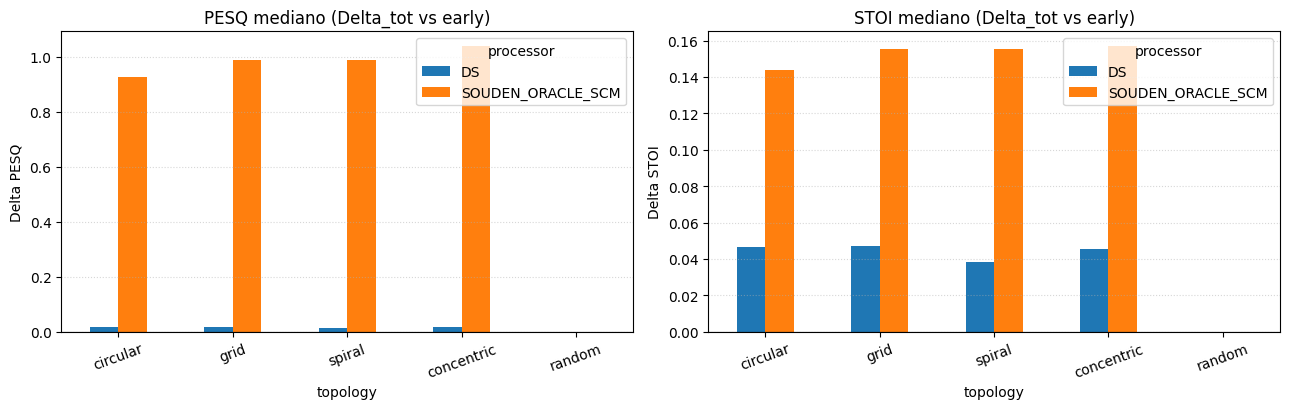

In [18]:
# Barras: SIR y STOI MEDIANOS por topologia y algoritmo
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, metric in zip(axes, ['PESQ', 'STOI']):
    piv = view.pivot_table(index='topology', columns='processor', values=metric,
                           aggfunc='median', observed=True).reindex(topo_order)
    piv.plot(kind='bar', ax=ax, rot=20)
    ax.set_title(f'{metric} mediano (Delta_tot vs {REF})')
    ax.set_ylabel(f'Delta {metric}'); ax.axhline(0, color='k', lw=0.8)
    ax.grid(True, axis='y', ls=':', alpha=0.5)
plt.tight_layout(); plt.show()

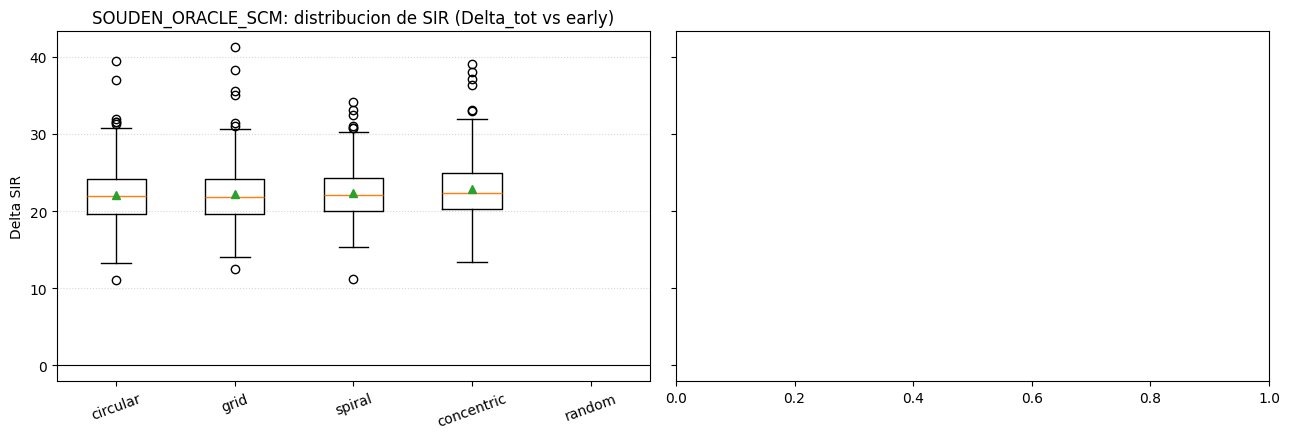

In [19]:
# Dispersion escena-a-escena: boxplot de SIR por topologia (una caja = N_SCENES*3 salas)
# La MEDIANA rankea, pero el ancho de la caja dice que topologia es mas CONSISTENTE.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, proc in zip(axes, [ 'SOUDEN_ORACLE_SCM']):
    data = [view[(view['processor'] == proc) & (view['topology'] == t)]['SIR'].dropna().values
            for t in topo_order]
    ax.boxplot(data, tick_labels=topo_order, showmeans=True)
    ax.set_title(f'{proc}: distribucion de SIR (Delta_tot vs {REF})')
    ax.set_ylabel(f'Delta SIR'); ax.axhline(0, color='k', lw=0.8)
    ax.grid(True, axis='y', ls=':', alpha=0.5); ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()